# tSZ power spectrum under $(M_{500c}, z)$ masking

This repeats the nb14 comparison, the NaMaster map power spectrum versus the **catalogue
discrete 1-halo sum** over the surviving halos, but the masking is now a **direct top-hat in
$(M_{500c}, z)$** rather than an SNR threshold $q$:

- **Mass progression.** Mask (remove) the most massive clusters, $M_{500c}>M_{\rm cut}$, for a few
  decreasing $M_{\rm cut}$. Survivors are $M_{500c}<M_{\rm cut}$. Massive clusters carry large discs and
  dominate the intermediate-$\ell$ tSZ power, so the spectrum should drop as $M_{\rm cut}$ falls.
- **Redshift progression.** Mask the **nearby** clusters, $z<z_{\rm cut}$, for a few increasing
  $z_{\rm cut}$. Survivors are $z>z_{\rm cut}$. Low-$z$ clusters have the largest angular size and
  source the lowest multipoles.

**Map side.** For each selection we cut a $5\,\theta_{500}$ disc around every masked cluster, apodize
the mask, and estimate the mask-decoupled bandpowers with **NaMaster** (mode-coupling deconvolution,
mask-weighted monopole subtracted), then deconvolve the HEALPix pixel window.

**Catalogue side.** We sum the GNFW ($B=1$) harmonic profile over the **survivors**, exactly as in
nb14, $C_\ell^{1h}=\frac{1}{4\pi}\sum_{i\in\rm surv}|y_\ell(M_i,z_i)|^2$ with
$y_\ell=Y_{\rm ang}\hat G(\ell\theta_{500})$, and compare to the masked-map datapoints.


In [1]:
import os
os.environ.setdefault('OMP_NUM_THREADS', '64')        # NaMaster threading on orion

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

# Publication-quality plot defaults
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})


from flamingo import paths
from flamingo.maps import read_map
from flamingo.catalogue import load_catalogue
from flamingo.geometry import query_disc_separation, ARCMIN_PER_RAD
from flamingo.powerspectra import apodize, decoupled_dl
from hmfast.halos.profiles import GNFWPressureProfile

LMAX, DELL, R_MASK = 6000, 30, 5.0

# ---- catalogues (rows align 1:1) ----
# y0q csv: B=1 Y_5R500c / theta500 -> discrete-sum amplitude & shape (as in nb14).
# original catalogue: sky positions (theta_rot, phi_rot) for the map mask.
y0q = load_catalogue(paths.HYDRO / 'catalogue' / 'halo_catalogue_M500c_5e13_zlt3_y0q_arnaudB1.csv')
orig = load_catalogue(paths.HYDRO_CATALOGUE)
assert len(y0q) == len(orig)
assert np.allclose(y0q['M_500c_Msun'].values, orig['M_500c_Msun'].values)

good = (y0q['Y_5R500c_Mpc2'].values > 0) & (y0q['R_500c_Mpc'].values > 0)
y0q, orig = y0q[good].reset_index(drop=True), orig[good].reset_index(drop=True)

M500 = y0q['M_500c_Msun'].values                       # Msun
zc = y0q['z'].values
R500 = y0q['R_500c_Mpc'].values                        # proper Mpc
Ympc2 = y0q['Y_5R500c_Mpc2'].values                    # = D_A^2 Y_sph, proper Mpc^2
th500 = y0q['theta500_arcmin'].values / ARCMIN_PER_RAD # proper, radians (B=1)
Yang = Ympc2 * (th500 / R500) ** 2                     # = Y_5R500c / D_A^2  [sr]

theta_rot = orig['theta_rot_rad'].values               # sky colatitude
phi_rot = orig['phi_rot_rad'].values                   # sky longitude

ymap = read_map(paths.HYDRO_MAP)
NSIDE = hp.npix2nside(ymap.size)
print(f'clusters {len(y0q)} | NSIDE {NSIDE}')
print(f'full-sky white plateau C_white = sum(Y_ang^2)/4pi = {np.sum(Yang**2)/(4*np.pi):.3e} sr')


clusters 1555542 | NSIDE 4096
full-sky white plateau C_white = sum(Y_ang^2)/4pi = 2.943e-16 sr


## Selections in $(M_{500c}, z)$

We define one progression that masks the high-mass clusters and one that masks the low-$z$ clusters.
Each entry stores a boolean `masked` (cut from the map and dropped from the catalogue sum) so that the
**survivors** `~masked` source both the masked map and the discrete sum.


In [2]:
MASS_CUTS = [1e15, 5e14, 2e14]        # mask M500c > M_cut
Z_CUTS = [0.01, 0.05, 0.1, 0.25]      # mask z < z_cut

selections = {}
for Mc in MASS_CUTS:
    selections[f'M>{Mc:.0e}'] = (M500 > Mc)
for zc_ in Z_CUTS:
    selections[f'z<{zc_}'] = (zc < zc_)

for name, masked in selections.items():
    print(f'{name:>10s}: mask {int(masked.sum()):>7d}  -> survivors {int((~masked).sum()):>7d}')


   M>1e+15: mask     242  -> survivors 1555300
   M>5e+14: mask    3738  -> survivors 1551804
   M>2e+14: mask   64647  -> survivors 1490895
    z<0.01: mask      15  -> survivors 1555527
    z<0.05: mask     720  -> survivors 1554822
     z<0.1: mask    4731  -> survivors 1550811
    z<0.25: mask   57283  -> survivors 1498259


## Universal GNFW form factor (nb14)

The Arnaud GNFW shape is fixed and calibrated at $500c$; the catalogue gives $M_{500c}$, $R_{500c}$, so
the form factor is the normalised 3D sinc (Komatsu-Seljak / Limber) transform of the fixed shape,
$\hat G(u)=\frac{1}{I_5}\int_0^5 x^2 p(x)\frac{\sin ux}{ux}\,dx$, $u=\ell\theta_{500}$, with shape
parameters taken from hmfast's `GNFWPressureProfile`.


In [3]:
from scipy.integrate import quad

prof = GNFWPressureProfile(B=1.0)
P0, c500, al, be, ga = prof.P0, prof.c500, prof.alpha, prof.beta, prof.gamma

def p_shape(x):
    cx = c500 * np.maximum(x, 1e-12)
    return cx ** (-ga) * (1 + cx ** al) ** ((ga - be) / al)

I5 = quad(lambda x: p_shape(x) * x * x, 0, 5, limit=400)[0]
u_tab = np.geomspace(1e-3, 400.0, 600)
G_tab = np.array([quad(lambda x: p_shape(x) * x * x * np.sinc(u * x / np.pi), 0, 5, limit=400)[0] / I5
                  for u in u_tab])

def Ghat(u):
    return np.interp(np.clip(u, u_tab[0], u_tab[-1]), u_tab, G_tab)

def cl_1h(ell_arr, surv):
    w2, t = Yang[surv] ** 2, th500[surv]
    return np.array([np.sum(w2 * Ghat(l * t) ** 2) / (4 * np.pi) for l in ell_arr])

def to_dl(ell_arr, cl):
    return ell_arr * (ell_arr + 1) * cl / (2 * np.pi)


E0615 17:10:28.270548 1904045 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 71.23GiB (76478791680 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0615 17:10:28.271252 1904045 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 64.10GiB (68830912512 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory


## Masked-map power spectra (NaMaster)

For each selection we zero a $5\,\theta_{500}$ disc around every masked cluster, apodize ($0.5^\circ$),
and run the mask-decoupled estimator, then deconvolve the pixel window. This is the expensive step
(one coupling matrix per mask at $\ell_{\max}=6000$), so results are cached to
`data/nb15_mz_masked_ps.npz`; delete that file to force a recompute.


In [4]:
cache = paths.DATA / 'nb15_mz_masked_ps.npz'
pwf = hp.pixwin(NSIDE, lmax=LMAX)

def dl_nmt(weight):
    ell_eff, _, cl = decoupled_dl(ymap, weight, delta_ell=DELL, lmax=LMAX)
    cl = cl / np.interp(ell_eff, np.arange(pwf.size), pwf) ** 2
    return ell_eff, to_dl(ell_eff, cl)

def build_mask(masked):
    mask = np.ones(ymap.size, dtype=np.float64)
    tc, pc, rad = theta_rot[masked], phi_rot[masked], R_MASK * th500[masked]
    for i in range(tc.size):
        pix, _ = query_disc_separation(NSIDE, float(tc[i]), float(pc[i]), float(rad[i]))
        mask[pix] = 0.0
    return mask

# Incremental cache: load whatever exists, compute only the missing selections.
if cache.exists():
    d = np.load(cache, allow_pickle=True)
    ellb = d['ellb']
    dl_map = {k[3:]: d[k] for k in d.files if k.startswith('dl_')}
    fsky = dict(d['fsky'].item())
    print('loaded', cache.name, '|', list(dl_map))
else:
    ellb, dl_map, fsky = None, {}, {}

todo = [('fullsky', None), *selections.items()]
new = 0
for name, masked in todo:
    if name in dl_map:
        continue
    if masked is None:
        ellb, dl_map[name] = dl_nmt(None)
        fsky[name] = 1.0
    else:
        mask = build_mask(masked)
        ellb, dl_map[name] = dl_nmt(apodize(mask, aperture_deg=0.5))
        fsky[name] = float(mask.mean())
    new += 1
    print(f'{name:>10s}: f_sky(binary)={fsky[name]:.4f}  computed')

if new:
    np.savez(cache, ellb=ellb, fsky=fsky, **{f'dl_{k}': v for k, v in dl_map.items()})
    print(f'wrote {cache.name} ({new} new)')
print('bandpowers:', f'{ellb.min():.0f} -> {ellb.max():.0f}')


loaded nb15_mz_masked_ps.npz | ['fullsky', 'M>1e+15', 'M>5e+14', 'M>2e+14', 'z<0.1', 'z<0.25', 'z<0.01', 'z<0.05']
bandpowers: 16 -> 5956


## Catalogue discrete sum over survivors

The same $\ell$ grid (extended to low $\ell$ to show the white plateau) summed over the survivors of
each selection, plus the full-sky sum.


In [5]:
ell_fine = np.geomspace(5.0, 8000.0, 70)
allsel = np.zeros(len(M500), dtype=bool)               # nothing masked -> full sky

dl_cat_fine, dl_cat_b, ratio, cw = {}, {}, {}, {}
sel_ell = (ellb > 400) & (ellb < 6000)

for key, masked in {'fullsky': allsel, **selections}.items():
    surv = ~masked
    dl_cat_fine[key] = to_dl(ell_fine, cl_1h(ell_fine, surv))
    dl_cat_b[key] = to_dl(ellb, cl_1h(ellb, surv))
    cw[key] = np.sum(Yang[surv] ** 2) / (4 * np.pi)    # ell->0 white plateau
    r = dl_cat_b[key] / dl_map[key]
    ratio[key] = r
    print(f'{key:>10s}: median(cat-sum / map), 400<l<6000 = {np.median(r[sel_ell]):.3f}')


   fullsky: median(cat-sum / map), 400<l<6000 = 1.028


   M>1e+15: median(cat-sum / map), 400<l<6000 = 1.054


   M>5e+14: median(cat-sum / map), 400<l<6000 = 1.114


   M>2e+14: median(cat-sum / map), 400<l<6000 = 1.189


    z<0.01: median(cat-sum / map), 400<l<6000 = 1.029


    z<0.05: median(cat-sum / map), 400<l<6000 = 1.031


     z<0.1: median(cat-sum / map), 400<l<6000 = 1.015


    z<0.25: median(cat-sum / map), 400<l<6000 = 0.963


## Figure

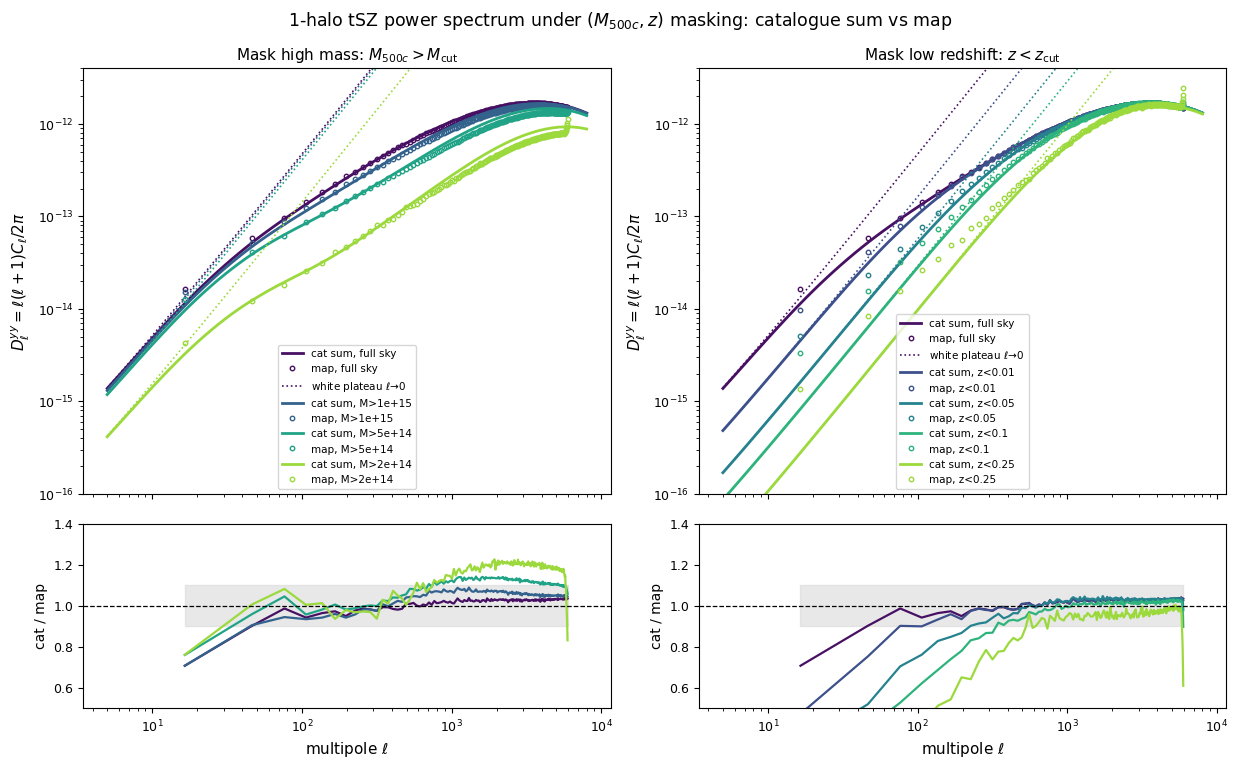

In [6]:
def panel(ax, axr, keys, title):
    colors = plt.cm.viridis(np.linspace(0.04, 0.85, len(keys)))
    for c, key in zip(colors, keys):
        lab = 'full sky' if key == 'fullsky' else key
        ax.plot(ell_fine, dl_cat_fine[key], color=c, lw=2.0, label=f'cat sum, {lab}')
        ax.plot(ellb, dl_map[key], 'o', color=c, ms=3.2, mfc='none', label=f'map, {lab}')
        wlab = r'white plateau $\ell\!\to\!0$' if key == keys[0] else None
        ax.plot(ell_fine, to_dl(ell_fine, cw[key]), ':', color=c, lw=1.2, label=wlab)
        axr.plot(ellb, ratio[key], color=c, lw=1.6)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_ylabel(r'$D_\ell^{yy}=\ell(\ell+1)C_\ell/2\pi$', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=7.5, loc='lower center', ncol=1)
    ax.set_ylim(1e-16, 4e-12); ax.tick_params(labelsize=9)
    axr.axhline(1.0, color='k', lw=0.9, ls='--')
    axr.fill_between([ellb.min(), ellb.max()], 0.9, 1.1, color='0.85', alpha=0.6)
    axr.set_xlabel(r'multipole $\ell$', fontsize=11)
    axr.set_ylabel('cat / map', fontsize=10)
    axr.set_ylim(0.5, 1.4); axr.tick_params(labelsize=9)

fig, axes = plt.subplots(2, 2, figsize=(12.5, 7.8), sharex='col',
                         gridspec_kw={'height_ratios': [3, 1.3]})
panel(axes[0, 0], axes[1, 0], ['fullsky', *[f'M>{m:.0e}' for m in MASS_CUTS]],
      r'Mask high mass: $M_{500c}>M_{\rm cut}$')
panel(axes[0, 1], axes[1, 1], ['fullsky', *[f'z<{z}' for z in Z_CUTS]],
      r'Mask low redshift: $z<z_{\rm cut}$')
fig.suptitle('1-halo tSZ power spectrum under $(M_{500c},z)$ masking: catalogue sum vs map',
             fontsize=12.5)
fig.tight_layout()
fig.savefig('../autoresearch/figures/nb15_mz_masked_tsz_ps.pdf')
fig.savefig('../autoresearch/figures/nb15_mz_masked_tsz_ps.png', dpi=300)
plt.show()


## Notes

- **1-halo only**, as in nb14: the low-$\ell$ deficit (ratio $<1$ at $\ell\lesssim300$) is the omitted
  2-halo clustering term. At high $\ell$ the catalogue sum tracks the masked map.
- **Mass masking** removes the rare massive clusters: large discs, few of them, so little sky is lost
  but the intermediate/high-$\ell$ power drops sharply (these objects have the largest $Y_{\rm ang}$).
- **Redshift masking** removes the nearby, large-angular-size clusters: this lowers the spectrum across
  $\ell$ and removes the largest-$\theta_{500}$ contributions to the lowest multipoles.
- The map mask also removes a little sky and any neighbours inside each disc, so the masked-map PS is a
  touch below the survivor catalogue sum; exact agreement on the cuts is not expected (same caveat as
  the SNR cuts in nb14).
